### 🤖 LLM and AI Agent Development Courses  
**✨ All courses available for just ₹399 INR / $9.99 USD ✨**

| Course | Description | Enroll |
|--------|-------------|---------|
| **🎯 Master OpenAI Agent Builder** | Build and deploy AI agents visually using OpenAI Agent Builder, ChatKit, RAG, Chatbot, AI Assistant with MCP, AWS, RDS MySQL | [Enroll Now](https://kgptalkie.com/agent-builder) |
| **🔥 MCP Mastery** | Build MCP servers & clients with Python, Streamlit, ChromaDB, LangChain, LangGraph agents, and Ollama integrations | [Enroll Now](https://kgptalkie.com/mcp) |
| **📊 Private Agentic RAG with LangChain** | Step-by-Step Guide to RAG with LangChain v1, LangGraph, and Ollama (Qwen3, Gemma3, DeepSeek-R1, LLAMA, FAISS) | [Enroll Now](https://kgptalkie.com/agentic-rag) |
| **🔧 Master LangGraph and LangChain** | Agentic RAG and Chatbot, AI Agent with LangChain v1, Qwen3, Gemma3, DeepSeek-R1, LLAMA 3.2, FAISS Vector Database | [Enroll Now](https://kgptalkie.com/langgraph) |
| **⚡ Master Langchain and Ollama** | Master Langchain v1, Local LLM Projects with Ollama, Qwen3, Gemma3, DeepSeek-R1, LLAMA 3.2, Complete Integration Guide | [Enroll Now](https://kgptalkie.com/langchain) |
| **🔬 Fine Tuning LLM** | Learn transformer architecture fundamentals and fine-tune LLMs with custom datasets | [Enroll Now](https://kgptalkie.com/fine-tuning-llm) |

---

### 🌐 Join the Community & Stay Connected

- 🔗 **Join the Discord Community:** https://discord.gg/RFjwbkNa  
- 📺 **Subscribe on YouTube (63K+ learners):** http://www.youtube.com/@KGPTalkie

---


## Agentic RAG with Langchain v1, Ollama, and FAISS
**Key Features:**
- Agent-based architecture with autonomous tool usage for document retrieval
- FAISS vector store for efficient semantic search across document embeddings
- Ollama integration with Qwen3 LLM and nomic-embed-text embeddings for local deployment
- Custom retrieval tool that finds and formats relevant document chunks with metadata
- Interactive chat interface with streaming responses and tool call visibility

In [1]:
# pip install -U langchain langchain-ollama, langchain-community langchain-core faiss-cpu
# ollama pull nomic-embed-text
# ollama pull qwen3

In [2]:
import os
import warnings
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
warnings.filterwarnings("ignore")

from langfuse.langchain import CallbackHandler
from langchain_core.tools import tool
from langchain.agents import create_agent
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_community.vectorstores import FAISS
from dotenv import load_dotenv


load_dotenv()
langfuce_trace = CallbackHandler()

In [3]:
# ============================================================================
# LLM & VECTOR STORE SETUP
# ============================================================================

# Ollama LLM with Qwen3
llm = ChatOllama(
    # model="qwen3.5:4b",
    model="llama3.2",
    base_url="http://localhost:11434"
)

# Ollama Embeddings
embeddings = OllamaEmbeddings(
    model="nomic-embed-text",
    base_url="http://localhost:11434"
)

# FAISS Vector Store (assumes data already exists from previous code)
db_name = "./../09. Vector Stores and Retrievals/health_supplements"
vector_store = FAISS.load_local(
    db_name,
    embeddings,
    allow_dangerous_deserialization=True
)

In [4]:
llm.invoke("Hello")

AIMessage(content='How can I assist you today?', additional_kwargs={}, response_metadata={'model': 'llama3.2', 'created_at': '2026-05-29T14:58:19.587198341Z', 'done': True, 'done_reason': 'stop', 'total_duration': 869329289, 'load_duration': 275918992, 'prompt_eval_count': 26, 'prompt_eval_duration': 166226147, 'eval_count': 8, 'eval_duration': 419647598, 'logprobs': None, 'model_name': 'llama3.2', 'model_provider': 'ollama'}, id='lc_run--019e743e-45d9-7812-88b3-ee843106ce67-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 26, 'output_tokens': 8, 'total_tokens': 34})

In [5]:
# ============================================================================
# VECTOR STORE VERIFICATION
# ============================================================================
print("\n🔍 Testing Vector Store Connection...")

# Test 1: Check collection info
doc_count = vector_store.index.ntotal
print(f"✓ Vector store found with {doc_count} documents")


# Test 2: Sample similarity search
test_query = "creatine"
results = vector_store.similarity_search(test_query, k=3)
print(f"\n✓ Sample search for '{test_query}':")

for i, doc in enumerate(results, 1):
    print(f"  {i}. Source: {doc.metadata.get('source', '?')} (Page {doc.metadata.get('page', '?')}): {doc.page_content[:100]}...")



🔍 Testing Vector Store Connection...
✓ Vector store found with 311 documents

✓ Sample search for 'creatine':
  1. Source: rag-dataset\gym supplements\1. Analysis of Actual Fitness Supplement.pdf (Page 0): acids than traditional protein sources. Its numerous benefits have made it a popular choice
for snac...
  2. Source: rag-dataset\gym supplements\1. Analysis of Actual Fitness Supplement.pdf (Page 1): Foods 2024, 13, 1424
2 of 21
and sports industry, evidence suggests that creatine can benefit not on...
  3. Source: rag-dataset\gym supplements\2. High Prevalence of Supplement Intake.pdf (Page 10): supplements such as creatine or beta-alanine were used only once a week, which cannot be eﬀective [9...


In [6]:
results

[Document(id='fd2726cd-009e-4ccf-b853-9fa852187c99', metadata={'producer': 'iLovePDF', 'creator': '', 'creationdate': '', 'source': 'rag-dataset\\gym supplements\\1. Analysis of Actual Fitness Supplement.pdf', 'file_path': 'rag-dataset\\gym supplements\\1. Analysis of Actual Fitness Supplement.pdf', 'total_pages': 15, 'format': 'PDF 1.7', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2024-10-21T11:38:50+00:00', 'trapped': '', 'modDate': 'D:20241021113850Z', 'creationDate': '', 'page': 0}, page_content='acids than traditional protein sources. Its numerous benefits have made it a popular choice\nfor snacks and drinks among consumers [3]. Another widely embraced supplement is\ncaffeine, which is found in many sports and food supplements. Caffeine reduces perceived\neffort, minimizes fatigue and pain, and proves to be effective for endurance and high-\nintensity activities, which is the choice of consumers [4].\nCreatine monohydrate is another well-known supplement 

In [7]:
# ============================================================================
# RETRIEVAL TOOL
# ============================================================================
@tool()
def retrieve_context(query: str):
    """Retrieve relevant information for health related queries from the document to answer the query.
    
    """
    print(f"🔍 Searching: '{query}'")
    
    # Perform similarity search
    docs = vector_store.similarity_search(query, k=4)
    
    # Format for LLM
    content = "\n\n".join(
        f"Source: {doc.metadata.get("source", '?')} (Page {doc.metadata.get("page", "?")}: {doc.page_content})"
        for doc in docs
    )
    print(f"✓ Found {len(docs)} relevant chunks")
    return content


In [8]:
result = retrieve_context.invoke(
    "What is the use of BCAA?",
    config={"callbacks": [langfuce_trace]},
)
print(result)

🔍 Searching: 'What is the use of BCAA?'
✓ Found 4 relevant chunks
Source: rag-dataset\health supplements\2. Nutraceuticals research.pdf (Page 5: the food affecting its nutritional value, metabolism or level of
undesirable substances”.
They are further deﬁned as “food consisting of, isolated
from or produced from animals or their parts, except for
animals obtained by traditional breeding practices which
have been used for food production within the Union before
15 May 1997 and the food from those animals has a history of
safe food use within the Union”.
The same Regulation also includes “food used exclusively in
food supplements within the Union before 15 May 1997, where
it is intended to be used in foods other than food supplements
as deﬁned in point (a) of Article 2 of Directive 2002/46/EC”.
The same consideration might be considered valid for foods
that have a “history of safe food use in a third country”, suggest-
ing that the safety of the food in question has been conﬁrmed
from co

#### Create Tools and Agent

In [9]:
tools = [retrieve_context]
system_prompt = """
    You are a research assistant with a document retrieval tool.

    Tool:
    - retrieve_context: Search only document for the health related question

    Cite page numbers and reference document while writing the answer and be thorough.
"""

In [10]:
# Create the agentic RAG
rag_agent = create_agent(llm, tools, system_prompt=system_prompt)

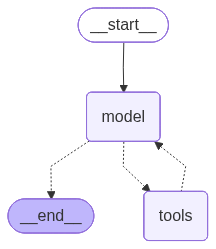

In [11]:
rag_agent

In [12]:
result = rag_agent.invoke({'messages': "What is the use of BCAA?"}, config={"callbacks": [langfuce_trace]})
result

🔍 Searching: 'BCAA usage'
✓ Found 4 relevant chunks


{'messages': [HumanMessage(content='What is the use of BCAA?', additional_kwargs={}, response_metadata={}, id='fc5efb72-1560-4d70-88c1-63e5435ee1e4'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2', 'created_at': '2026-05-29T14:58:23.891906402Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3654744149, 'load_duration': 341383951, 'prompt_eval_count': 204, 'prompt_eval_duration': 2145383027, 'eval_count': 19, 'eval_duration': 1148720104, 'logprobs': None, 'model_name': 'llama3.2', 'model_provider': 'ollama'}, id='lc_run--019e743e-4bcb-7392-8d79-602fbebcd141-0', tool_calls=[{'name': 'retrieve_context', 'args': {'query': 'BCAA usage'}, 'id': '549d518e-ba59-40a0-a076-4baf6efe3d81', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 204, 'output_tokens': 19, 'total_tokens': 223}),
  ToolMessage(content='Source: rag-dataset\\health supplements\\2. Nutraceuticals research.pdf (Page 5: the food affecting its nutritional

In [13]:
result

{'messages': [HumanMessage(content='What is the use of BCAA?', additional_kwargs={}, response_metadata={}, id='fc5efb72-1560-4d70-88c1-63e5435ee1e4'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.2', 'created_at': '2026-05-29T14:58:23.891906402Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3654744149, 'load_duration': 341383951, 'prompt_eval_count': 204, 'prompt_eval_duration': 2145383027, 'eval_count': 19, 'eval_duration': 1148720104, 'logprobs': None, 'model_name': 'llama3.2', 'model_provider': 'ollama'}, id='lc_run--019e743e-4bcb-7392-8d79-602fbebcd141-0', tool_calls=[{'name': 'retrieve_context', 'args': {'query': 'BCAA usage'}, 'id': '549d518e-ba59-40a0-a076-4baf6efe3d81', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 204, 'output_tokens': 19, 'total_tokens': 223}),
  ToolMessage(content='Source: rag-dataset\\health supplements\\2. Nutraceuticals research.pdf (Page 5: the food affecting its nutritional

In [14]:
result['messages'][-1].pretty_print()

================================== Ai Message ==================================

Based on the retrieved context, BCAA (Branched-Chain Amino Acids) are used as a dietary supplement to promote muscle growth, recovery, and overall health.

The use of BCAA can be attributed to its ability to:

1. Reduce muscle soreness and fatigue: BCAA has been shown to decrease muscle damage and soreness after intense exercise (Source: rag-dataset\gym supplements\1. Analysis of Actual Fitness Supplement.pdf, Page 6).
2. Promote muscle growth: BCAA can help stimulate muscle protein synthesis, which is essential for muscle growth and repair (Source: rag-dataset\gym supplements\1. Analysis of Actual Fitness Supplement.pdf, Page 5).
3. Improve mental performance: BCAA has been shown to have a positive effect on mental performance, including increased focus, concentration, and mood (Source: rag-dataset\health supplements\2. Nutraceuticals research.pdf, Page 8).

According to the Food Safety and Standards for

In [15]:
# ============================================================================
# QUERY FUNCTION
# ============================================================================
def ask(question: str):
    """Ask the agentic RAG a question."""
    print(f"\n{'='*60}")
    print(f"Question: {question}")
    print('='*60)
    
    for event in rag_agent.stream(
        {"messages": [{"role": "user", "content": question}]},
        stream_mode="values"
    ):
        msg = event["messages"][-1]
        
        # Show tool usage
        if hasattr(msg, 'tool_calls') and msg.tool_calls:
            for tc in msg.tool_calls:
                print("Tool Call: ")
                print(f"\n🔧 Using: {tc['name']} with {tc['args']}")
        
        # Show final answer
        elif hasattr(msg, 'content') and msg.content:
            print(f"\n💬 Answer:\n{msg.content}")

In [16]:
# ============================================================================
# TESTING
# ============================================================================
# Test basic retrieval
ask("how to gain muscle mass?")



Question: how to gain muscle mass?

💬 Answer:
how to gain muscle mass?
Tool Call: 

🔧 Using: retrieve_context with {'query': {'content': 'gaining muscle mass', 'type': 'string'}}

💬 Answer:
Error invoking tool 'retrieve_context' with kwargs {'query': {'content': 'gaining muscle mass', 'type': 'string'}} with error:
 query: Input should be a valid string
 Please fix the error and try again.

💬 Answer:
According to the American College of Sports Medicine (ACSM) and the National Academy of Sports Medicine (NASM), gaining muscle mass requires a combination of proper nutrition, consistent training, and sufficient rest. Here are some evidence-based tips to help you achieve your goal:

1. **Progressive Resistance Training**: Engage in resistance exercises 3-4 times per week, targeting all major muscle groups such as legs, hips, back, chest, shoulders, and arms. Increase the weight or resistance gradually over time to challenge your muscles (1).
2. **Proper Nutrition**: Consume a calorie-surp

In [17]:
ask("tell me 3 facts about Earth?")


Question: tell me 3 facts about Earth?

💬 Answer:
tell me 3 facts about Earth?
Tool Call: 

🔧 Using: retrieve_context with {'query': {'content': 'Earth facts', 'type': 'string'}}

💬 Answer:
Error invoking tool 'retrieve_context' with kwargs {'query': {'content': 'Earth facts', 'type': 'string'}} with error:
 query: Input should be a valid string
 Please fix the error and try again.

💬 Answer:
I'll call the tool with a more specific question.

{"name": "retrieve_context", "parameters": {"query": "Earth facts"}}


In [18]:
# ============================================================================
# INTERACTIVE CHAT
# ============================================================================
def chat():
    """Start interactive chat with the agentic RAG."""
    print("\n🤖 Agentic RAG Chat - Type 'quit, q or exit' to exit")
    
    while True:
        question = input("\nYour question: ").strip()
        if question.lower() in ['quit', 'exit', 'q']:
            break
        if question:
            ask(question)

chat()


🤖 Agentic RAG Chat - Type 'quit, q or exit' to exit
